# CS3807 – Deep Learning Laboratory
# Experiment 3: Implementation of CNNs for Image Classification

**Dataset:** CIFAR-10  |  **Random state:** 109 (fixed throughout for reproducibility)

**Note on fonts:** True *Times New Roman* is a Microsoft-licensed font and is not
freely installable on Linux/Colab. This notebook uses **Liberation Serif**,
which is metric-compatible with Times New Roman (same character widths/shape family)
and is the standard open substitute used when TNR itself isn't available. If you have
a licensed `.ttf` of Times New Roman, you can upload it and point `font_path` to it
instead — a commented-out line is provided in the font-setup cell for this.


In [1]:
# Core imports and reproducibility setup
import os, time, json, random, zipfile, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

SEED = 109
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", bool(gpus), gpus)
if not gpus:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU (T4) "
          "before continuing, or Task 6 training will be slow.")


TensorFlow version: 2.20.0
GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Plot styling setup — font size 13–15, serif (Times New Roman substitute), bold axes

In [2]:
# Font + plot style setup
!apt-get -qq install -y fonts-liberation > /dev/null 2>&1

# If you have a licensed Times New Roman .ttf, upload it and uncomment:
# from matplotlib import font_manager
# font_manager.fontManager.addfont('/content/times.ttf')
# mpl.rcParams['font.family'] = 'Times New Roman'

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Liberation Serif', 'Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size'] = 14          # 13-15pt requirement
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.labelweight'] = 'bold'   # bold axes requirement
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 13
mpl.rcParams['ytick.labelsize'] = 13
mpl.rcParams['legend.fontsize'] = 13
mpl.rcParams['figure.dpi'] = 150

PLOTS_DIR = '/content/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(PLOTS_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=150)
    print("Saved:", path)


## Task 1 — Load CIFAR-10, display samples, print dimensions, plot class distribution

**Dataset source:** downloading directly via the Kaggle API (`kagglehub`) from
[pankrzysiu/cifar10-python](https://www.kaggle.com/datasets/pankrzysiu/cifar10-python) —
no manual upload of the dataset itself, no upload-truncation risk. Requires your
`kaggle.json` (from Kaggle -> Settings -> API -> **Legacy API Credentials** ->
**Create Legacy API Key**) uploaded to the Colab sidebar first. File-based auth is used
rather than an interactive login prompt so this doesn't hang under "Run All". The exact
folder structure `kagglehub` produces isn't assumed — the code searches the downloaded
directory at runtime for `data_batch_1..5` and `test_batch` wherever they actually land,
and fails loudly with a directory listing if any are missing, rather than silently
guessing a path.

In [3]:
import os, shutil, pickle

# Place kaggle.json credentials where the Kaggle API expects them
os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_json_src = '/content/kaggle.json'  # update if the sidebar shows a different name
assert os.path.exists(kaggle_json_src), (
    f"kaggle.json not found at {kaggle_json_src} -- upload it to the Colab sidebar first "
    "(Kaggle -> Settings -> API -> Legacy API Credentials -> Create Legacy API Key)."
)
shutil.copy(kaggle_json_src, '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kagglehub
import kagglehub
dataset_path = kagglehub.dataset_download("pankrzysiu/cifar10-python")
print("Downloaded to:", dataset_path)

# 4) Find the batch files wherever kagglehub actually placed them -- not assumed
expected_files = [f'data_batch_{i}' for i in range(1, 6)] + ['test_batch']
found = {}
for root, _dirs, files in os.walk(dataset_path):
    for fname in files:
        if fname in expected_files:
            found[fname] = os.path.join(root, fname)

missing = [f for f in expected_files if f not in found]
if missing:
    listing = "\n".join(os.path.join(r, f) for r, _d, fs in os.walk(dataset_path) for f in fs)
    raise FileNotFoundError(
        f"Could not find these files anywhere under {dataset_path}: {missing}\n"
        f"Actual contents of {dataset_path}:\n{listing}"
    )
print("Located all batch files:")
for k, v in found.items():
    print(" ", k, "->", v)

def _load_batch(filepath):
    with open(filepath, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    data = d[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(d[b'labels'])
    return data, labels

xs, ys = [], []
for i in range(1, 6):
    data, labels = _load_batch(found[f'data_batch_{i}'])
    xs.append(data); ys.append(labels)
x_train = np.concatenate(xs)
y_train = np.concatenate(ys)
x_test, y_test = _load_batch(found['test_batch'])

y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)
print("Classes:", len(class_names))

x_train_n = x_train.astype('float32') / 255.0
x_test_n  = x_test.astype('float32') / 255.0
y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)


Using Colab cache for faster access to the 'cifar10-python' dataset.
Downloaded to: /kaggle/input/cifar10-python
Located all batch files:
  data_batch_1 -> /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_1
  data_batch_2 -> /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_2
  test_batch -> /kaggle/input/cifar10-python/cifar-10-batches-py/test_batch
  data_batch_3 -> /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_3
  data_batch_5 -> /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_5
  data_batch_4 -> /kaggle/input/cifar10-python/cifar-10-batches-py/data_batch_4
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000,)
Classes: 10


Saved: /content/plots/01_sample_images.png


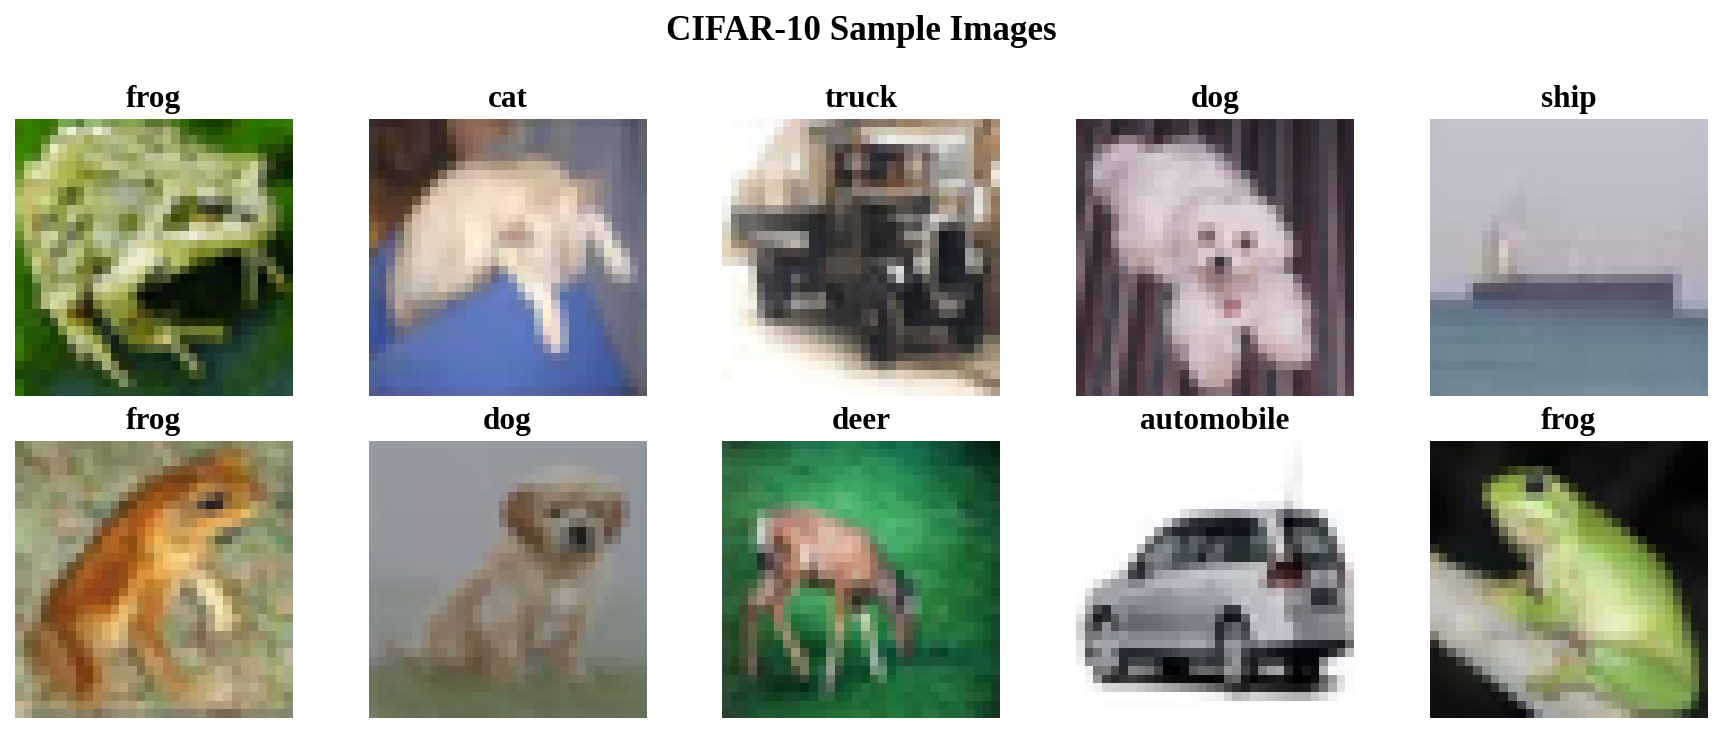

In [4]:
# Plot 1: Sample images
rng = np.random.RandomState(SEED)
idxs = rng.choice(len(x_train), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flat, idxs):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
fig.suptitle('CIFAR-10 Sample Images', fontweight='bold')
plt.tight_layout()
save_fig(fig, '01_sample_images.png')
plt.show()


Saved: /content/plots/02_class_distribution.png


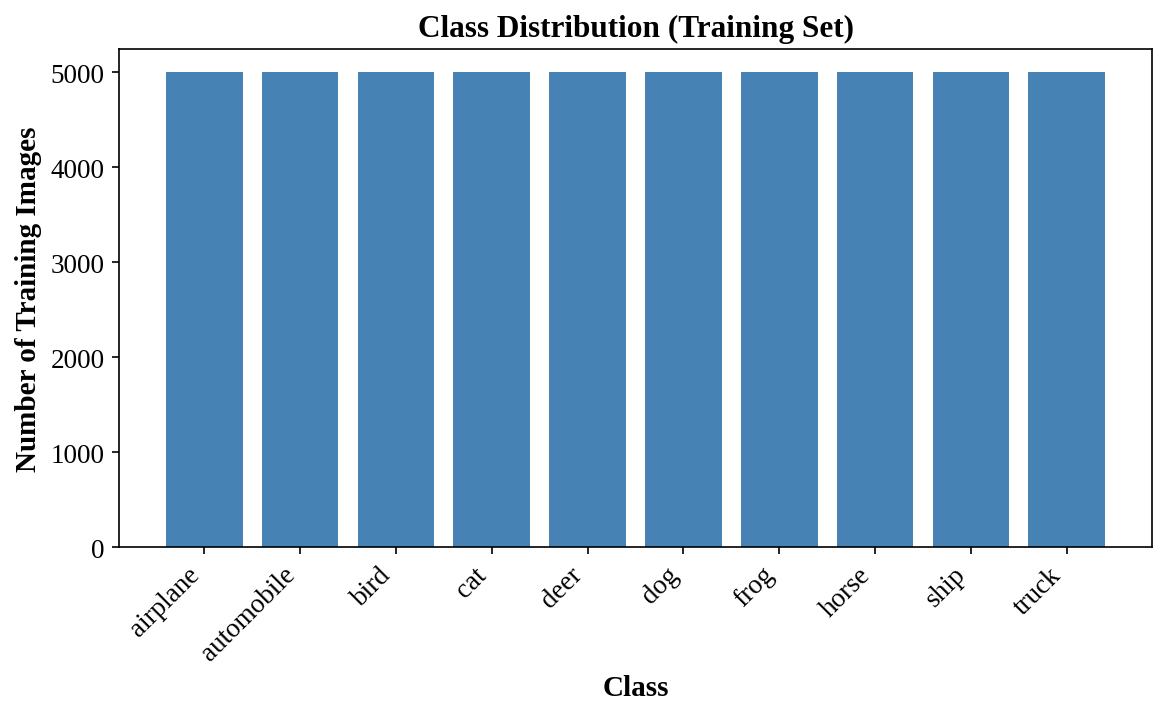

In [5]:
# Plot 2: Class distribution
counts = np.bincount(y_train)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(class_names, counts, color='steelblue')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Training Images')
ax.set_title('Class Distribution (Training Set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
save_fig(fig, '02_class_distribution.png')
plt.show()


## Task 2 — Convolution: kernel size comparison (3×3, 5×5, 7×7)
Output size formula: `(N - F + 2P) / S + 1`

In [6]:
def out_size(N, F, P, S):
    return (N - F + 2*P) // S + 1

N = 32  # CIFAR-10 image size
print(f"{'Kernel':<8}{'Padding':<10}{'Stride':<8}{'Output Size':<12}")
for F in [3, 5, 7]:
    print(f"{F}x{F:<6}{'Valid(0)':<10}{1:<8}{out_size(N,F,0,1)}")

# Demonstrate with actual Conv2D layers on one sample image
sample = x_train_n[0:1]
for F in [3, 5, 7]:
    conv = layers.Conv2D(8, F, strides=1, padding='valid')
    out = conv(sample)
    print(f"Kernel {F}x{F} -> feature map shape: {out.shape[1:]}")


Kernel  Padding   Stride  Output Size 
3x3     Valid(0)  1       30
5x5     Valid(0)  1       28
7x7     Valid(0)  1       26
Kernel 3x3 -> feature map shape: (30, 30, 8)
Kernel 5x5 -> feature map shape: (28, 28, 8)
Kernel 7x7 -> feature map shape: (26, 26, 8)


## Task 3 — Hyperparameter study: stride and padding

In [7]:
print(f"{'Stride':<10}{'Padding':<10}{'Output Size (F=3)':<20}")
for S in [1, 2]:
    for P_name, P_val, keras_pad in [('Valid', 0, 'valid'), ('Same', None, 'same')]:
        conv = layers.Conv2D(8, 3, strides=S, padding=keras_pad)
        out = conv(sample)
        print(f"{S:<10}{P_name:<10}{str(out.shape[1:]):<20}")


Stride    Padding   Output Size (F=3)   
1         Valid     (30, 30, 8)         
1         Same      (32, 32, 8)         
2         Valid     (15, 15, 8)         
2         Same      (16, 16, 8)         


## Task 4 — Feature map visualization (first convolution layer)

The lab manual does not specify trained vs. untrained weights for this task, so both
are generated on the same sample image and the same `conv1` layer for direct comparison:
- `07a_feature_maps_untrained.png` — generated right below, before any training happens
- `07b_feature_maps_trained.png` — generated later in the Task 6 section, after training,
  using this exact same model and image

Architecture used (same one built and trained in Task 6):
`Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax`

In [8]:
def build_cnn(pooling='max', filters=(16, 32)):
    # Strictly follows the manual's diagram:
    # Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax
    pool_layer = layers.MaxPooling2D if pooling == 'max' else layers.AveragePooling2D
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(filters[0], 3, padding='same', name='conv1'),
        layers.Activation('relu'),
        pool_layer(2),
        layers.Conv2D(filters[1], 3, padding='same', name='conv2'),
        layers.Activation('relu'),
        pool_layer(2),
        layers.Flatten(),
        layers.Dense(10, activation='softmax'),
    ])
    return model

main_model = build_cnn(pooling='max', filters=(16, 32))
main_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,578 (99.91 KB)

 Trainable params: 25,578 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

Saved: /content/plots/07a_feature_maps_untrained.png


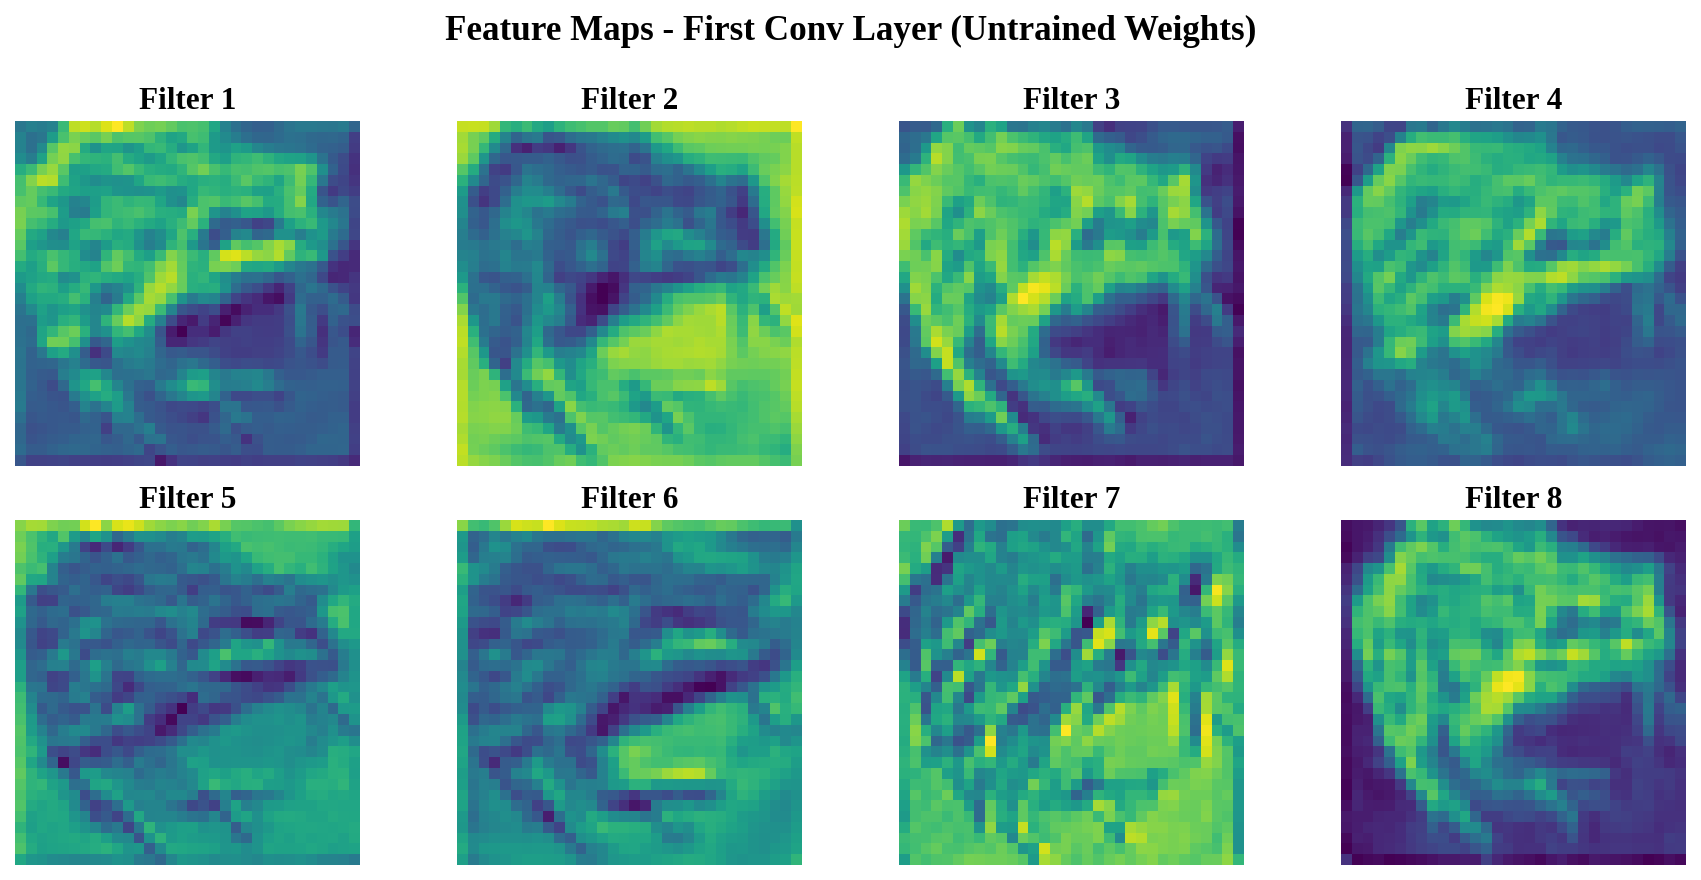

In [9]:
# Feature maps BEFORE training (random/untrained weights) - the "before" half of Task 4
feature_extractor_untrained = keras.Model(inputs=main_model.inputs,
                                           outputs=main_model.get_layer('conv1').output)
sample_img = x_train_n[idxs[0]:idxs[0]+1]
fmaps_untrained = feature_extractor_untrained.predict(sample_img, verbose=0)[0]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps_untrained[:, :, i], cmap='viridis')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')
fig.suptitle('Feature Maps - First Conv Layer (Untrained Weights)', fontweight='bold')
plt.tight_layout()
save_fig(fig, '07a_feature_maps_untrained.png')
plt.show()


## Task 6 — Build, compile and train the main CNN

**Time warning:** with a GPU (T4) runtime, 20 epochs on full CIFAR-10 (50,000 images,
batch size 32) should take roughly **2–5 minutes**. On CPU this would be 25–45+ minutes —
confirm `Runtime > Change runtime type > GPU` if the cell below looks like it's crawling.

In [10]:
main_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

start = time.time()
history = main_model.fit(
    x_train_n, y_train_oh,
    validation_data=(x_test_n, y_test_oh),
    epochs=20,
    batch_size=32,
    verbose=1
)
elapsed = time.time() - start
print(f"Total training time: {elapsed/60:.2f} minutes")


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.4740 - loss: 1.4887 - val_accuracy: 0.5747 - val_loss: 1.2142
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6010 - loss: 1.1537 - val_accuracy: 0.6180 - val_loss: 1.0995
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6423 - loss: 1.0392 - val_accuracy: 0.6387 - val_loss: 1.0417
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6669 - loss: 0.9684 - val_accuracy: 0.6524 - val_loss: 1.0024
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6865 - loss: 0.9144 - val_accuracy: 0.6616 - val_loss: 0.9778
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6992 - loss: 0.8742 - val_accuracy: 0.6713 - val_loss: 0.9572
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7115 - loss: 0.8418 - val_accuracy: 0.6752 - val_loss: 0.9482
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7204 - loss: 0.8144 

Saved: /content/plots/03_training_accuracy.png


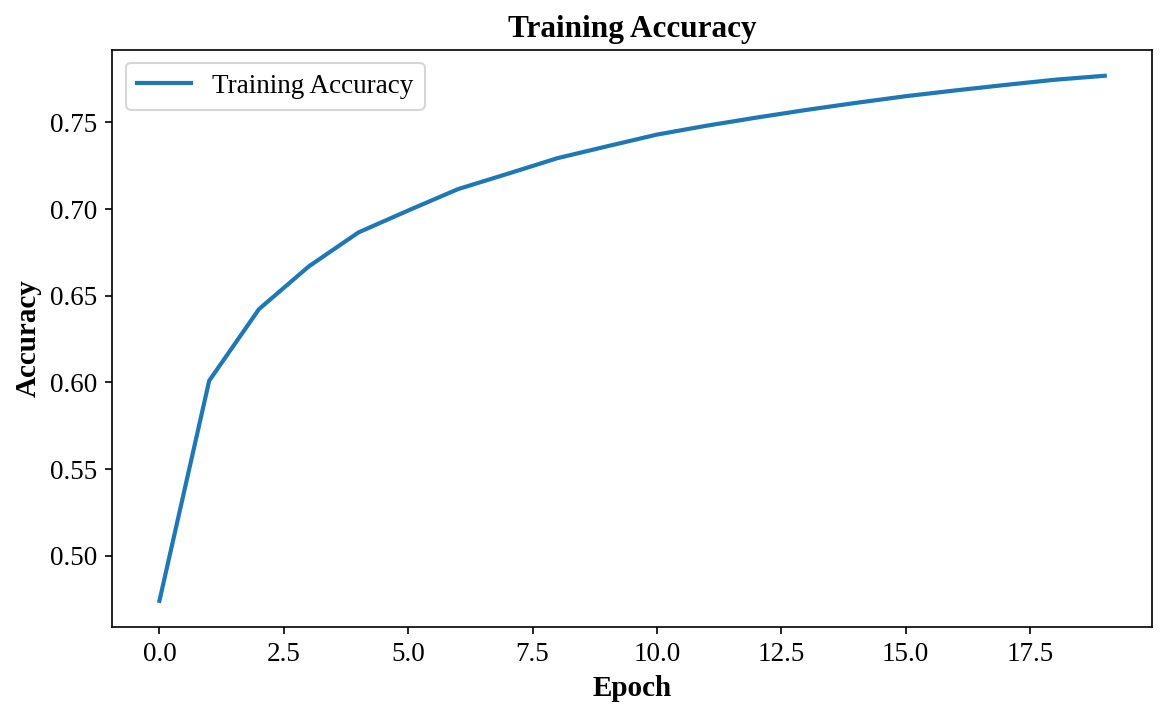

Saved: /content/plots/04_validation_accuracy.png


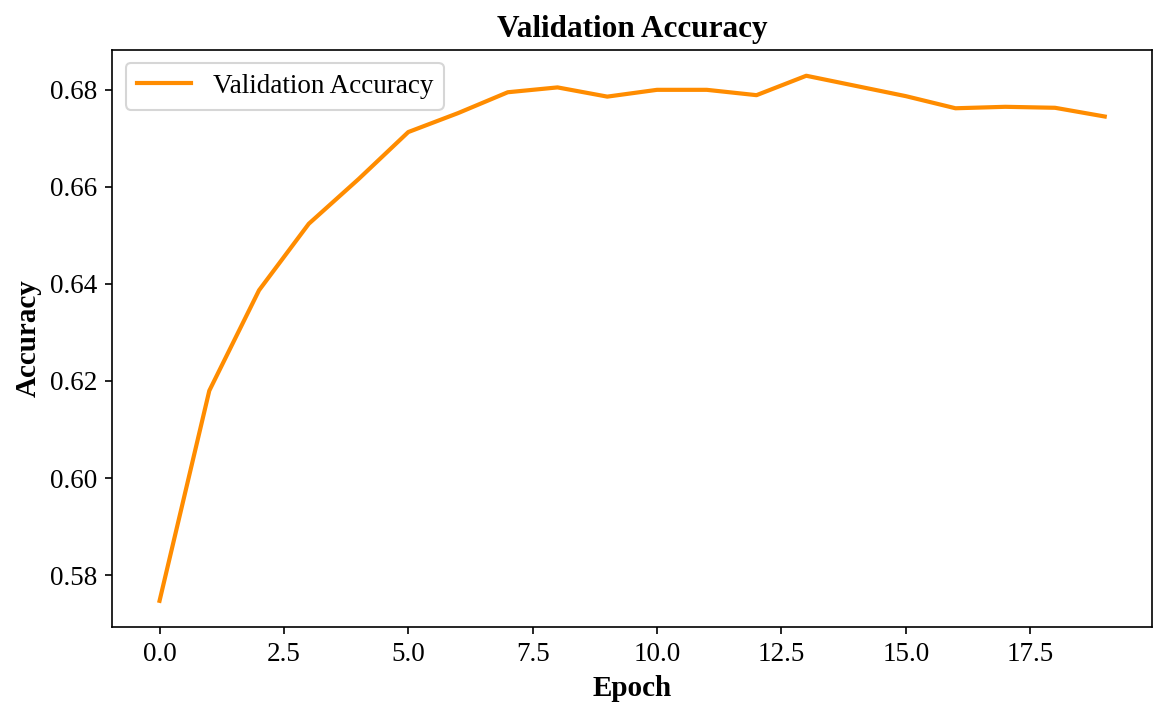

In [11]:
# Plots 3 & 4: Training / Validation Accuracy
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Training Accuracy')
ax.legend()
plt.tight_layout()
save_fig(fig, '03_training_accuracy.png')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Validation Accuracy')
ax.legend()
plt.tight_layout()
save_fig(fig, '04_validation_accuracy.png')
plt.show()


Saved: /content/plots/05_training_loss.png


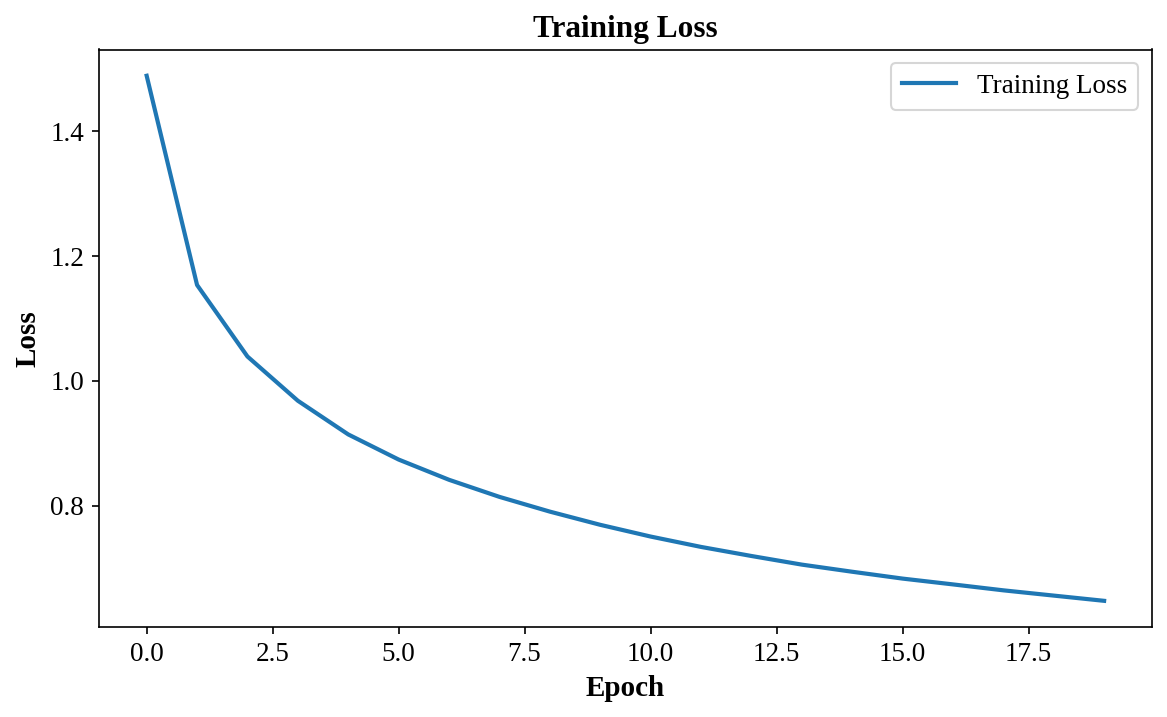

Saved: /content/plots/06_validation_loss.png


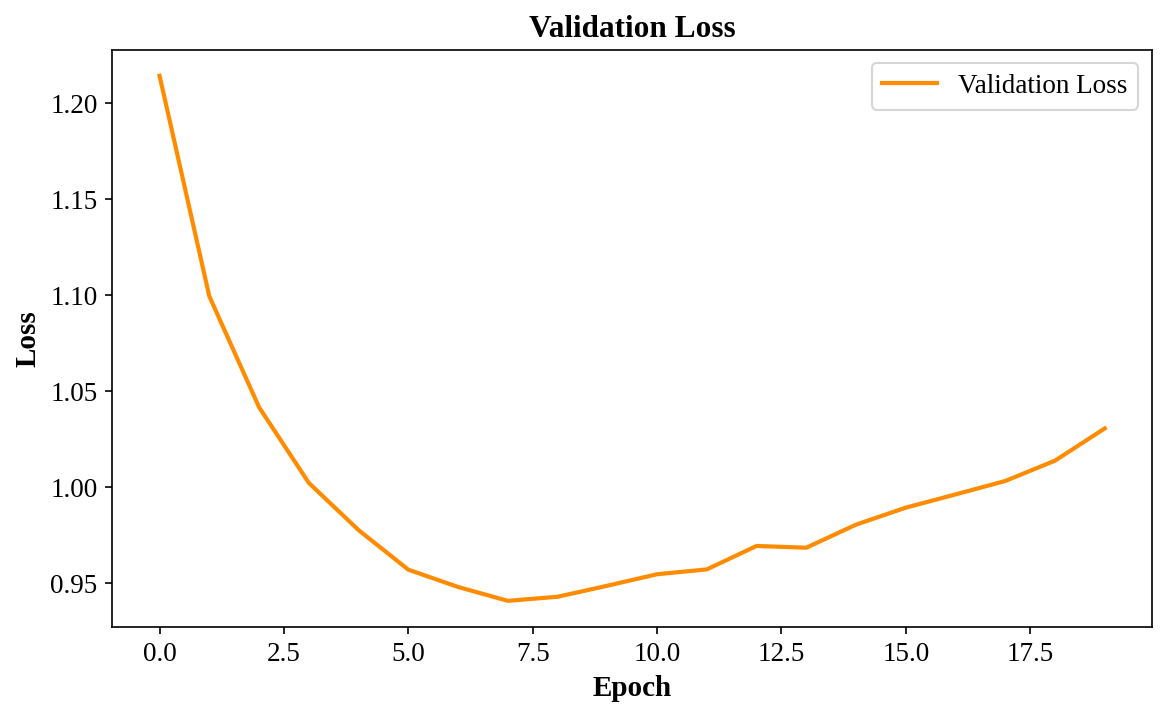

In [12]:
# Plots 5 & 6: Training / Validation Loss
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Training Loss')
ax.legend()
plt.tight_layout()
save_fig(fig, '05_training_loss.png')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Validation Loss')
ax.legend()
plt.tight_layout()
save_fig(fig, '06_validation_loss.png')
plt.show()


Saved: /content/plots/07b_feature_maps_trained.png


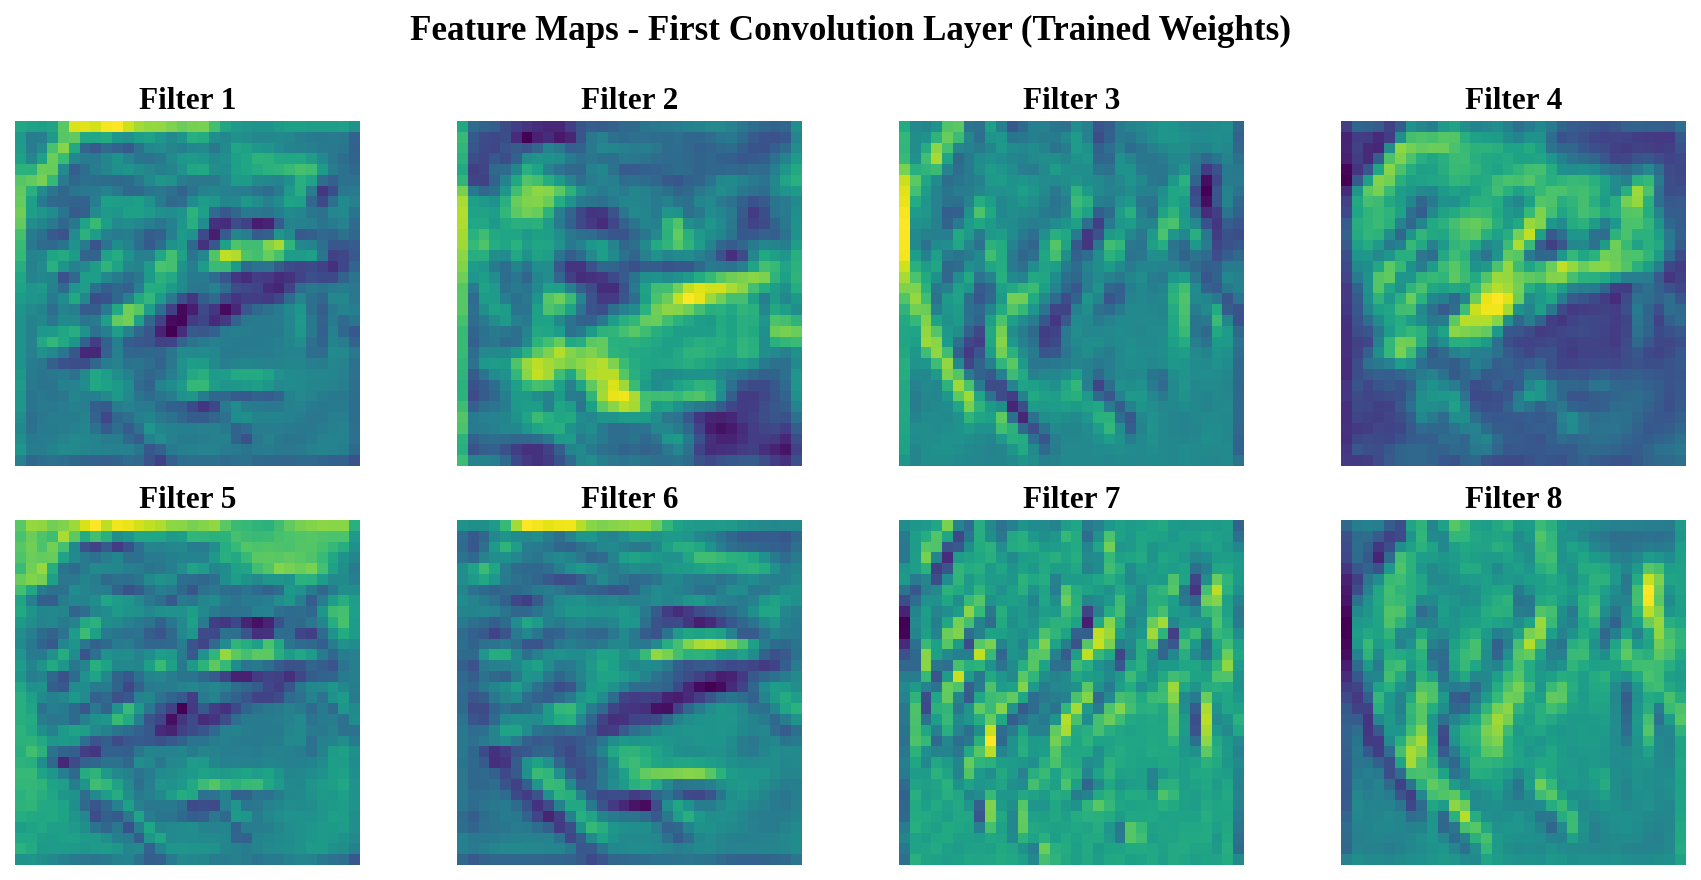

In [13]:
# Feature maps AFTER training (Task 4, "after" half) - same conv1 layer, same sample image,
# now using the weights learned in Task 6. Compare directly against 07a_feature_maps_untrained.png.
feature_extractor_trained = keras.Model(inputs=main_model.inputs,
                                         outputs=main_model.get_layer('conv1').output)
fmaps_trained = feature_extractor_trained.predict(sample_img, verbose=0)[0]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps_trained[:, :, i], cmap='viridis')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')
fig.suptitle('Feature Maps - First Convolution Layer (Trained Weights)', fontweight='bold')
plt.tight_layout()
save_fig(fig, '07b_feature_maps_trained.png')
plt.show()


## Task 7 — Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix

In [14]:
y_pred_probs = main_model.predict(x_test_n, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro)   : {rec:.4f}")
print(f"F1-score (macro) : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy : 0.6745
Precision (macro): 0.6823
Recall (macro)   : 0.6745
F1-score (macro) : 0.6740

              precision    recall  f1-score   support

    airplane       0.75      0.64      0.69      1000
  automobile       0.80      0.82      0.81      1000
        bird       0.52      0.62      0.57      1000
         cat       0.55      0.38      0.45      1000
        deer       0.54      0.69      0.61      1000
         dog       0.58      0.62      0.60      1000
        frog       0.72      0.75      0.73      1000
       horse       0.69      0.77      0.73      1000
        ship       0.83      0.75      0.79      1000
       truck       0.84      0.70      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.67     10000
weighted avg       0.68      0.67      0.67     10000



Saved: /content/plots/08_confusion_matrix.png


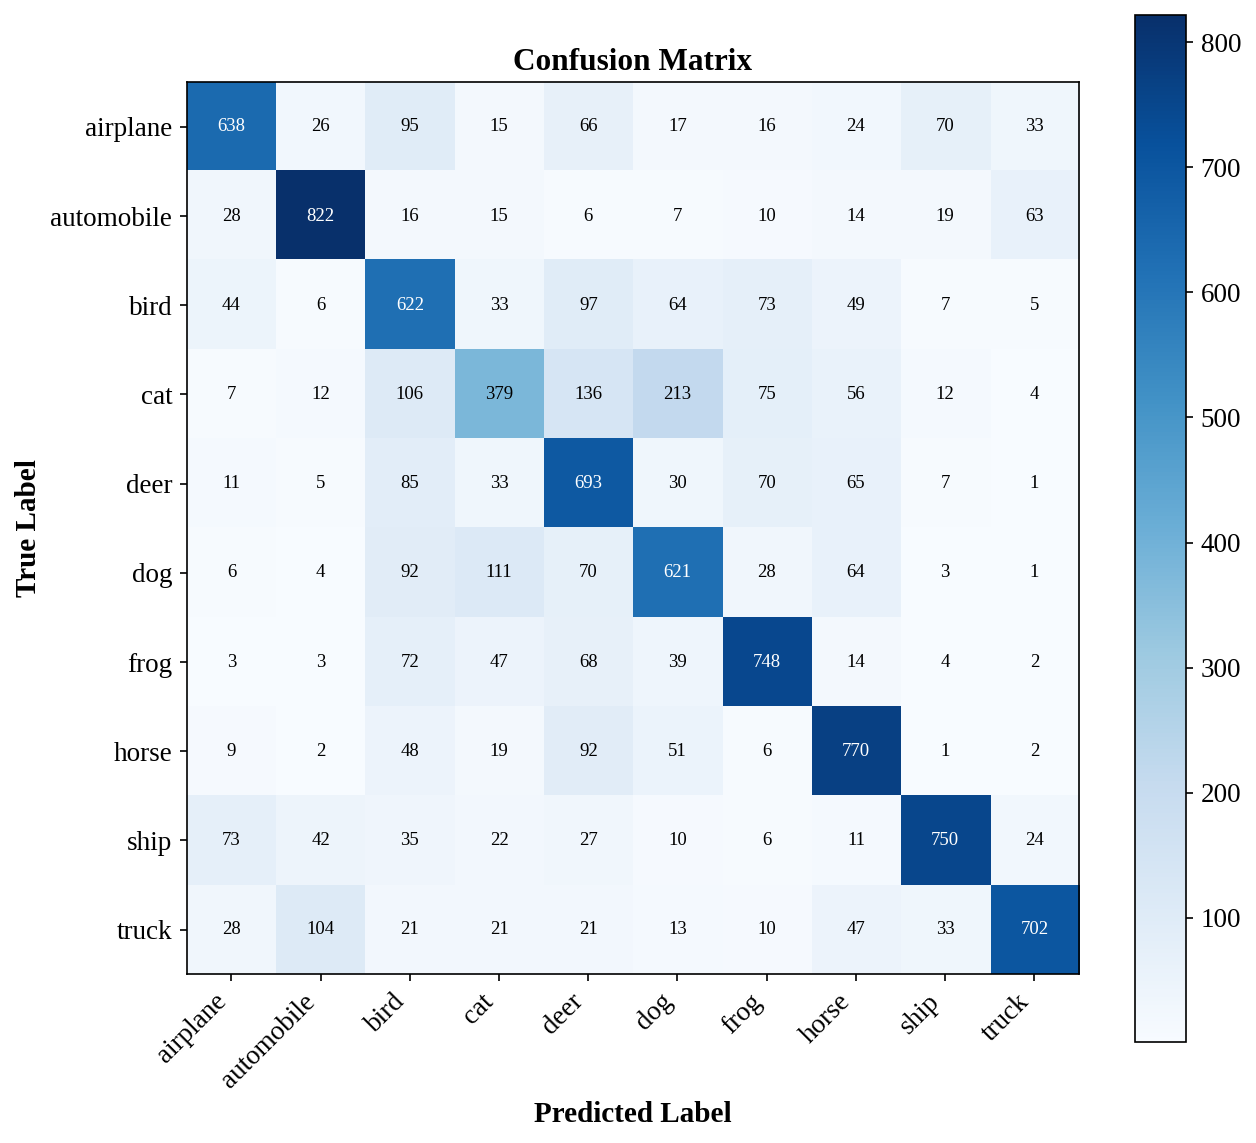

In [15]:
# Plot 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=9)
fig.colorbar(im)
plt.tight_layout()
save_fig(fig, '08_confusion_matrix.png')
plt.show()


## Task 5 — Max Pooling vs Average Pooling

**Time warning:** two additional models, 10 epochs each on GPU ≈ 1–2 minutes each
(chosen as the epoch count: full 20 epochs would double runtime for a secondary
comparison, while too few epochs wouldn't separate the two pooling strategies
meaningfully — 10 is the balance point on a GPU runtime).

In [16]:
POOL_EPOCHS = 10

model_max = build_cnn(pooling='max')
model_max.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Output size comparison (manual asks for this explicitly, separate from accuracy)
print("--- Output size comparison ---")
for layer in model_max.layers:
    if 'pooling' in layer.name:
        print(f"{layer.name:<25} output shape: {layer.output.shape}")
print("(Average pooling with the same kernel/stride produces identical output shapes "
      "to max pooling -- the two differ in the aggregation function, not the spatial "
      "output size.)")
print()

t0 = time.time()
hist_max = model_max.fit(x_train_n, y_train_oh, validation_data=(x_test_n, y_test_oh),
                          epochs=POOL_EPOCHS, batch_size=32, verbose=1)
time_max = time.time() - t0

model_avg = build_cnn(pooling='avg')
model_avg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
hist_avg = model_avg.fit(x_train_n, y_train_oh, validation_data=(x_test_n, y_test_oh),
                          epochs=POOL_EPOCHS, batch_size=32, verbose=1)
time_avg = time.time() - t0

print(f"Max Pooling  -> final val_accuracy: {hist_max.history['val_accuracy'][-1]:.4f}, time: {time_max:.1f}s")
print(f"Avg Pooling  -> final val_accuracy: {hist_avg.history['val_accuracy'][-1]:.4f}, time: {time_avg:.1f}s")


--- Output size comparison ---
max_pooling2d_2           output shape: (None, 16, 16, 16)
max_pooling2d_3           output shape: (None, 8, 8, 32)
(Average pooling with the same kernel/stride produces identical output shapes to max pooling -- the two differ in the aggregation function, not the spatial output size.)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4746 - loss: 1.4856 - val_accuracy: 0.5558 - val_loss: 1.2628
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6004 - loss: 1.1521 - val_accuracy: 0.6119 - val_loss: 1.1095
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6415 - loss: 1.0323 - val_accuracy: 0.6295 - val_loss: 1.0570
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6677 - loss: 0.9646 - val_accuracy: 0.6493 - val_loss: 1.0106
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6833 - loss: 0.9168 - val_accuracy: 0.6580 - val_loss: 0.9885
Epoch 6/10
1563/1563 ━━━━━━━━━━

Saved: /content/plots/09_pooling_comparison.png


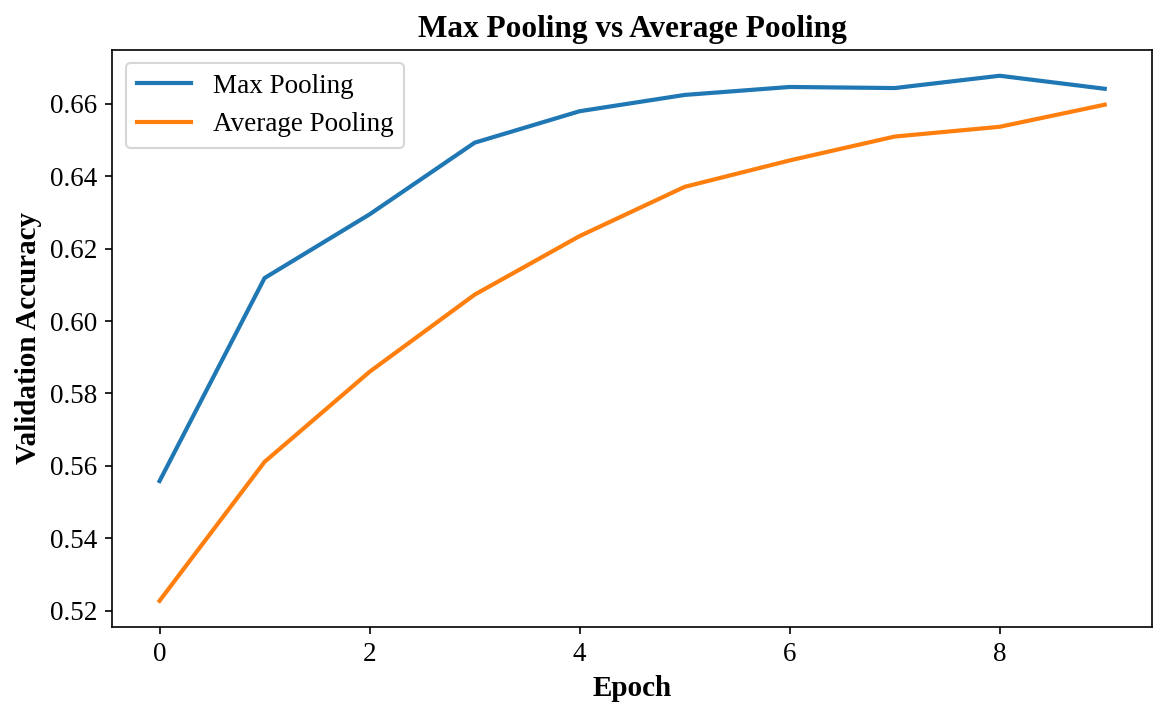

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_max.history['val_accuracy'], label='Max Pooling', linewidth=2)
ax.plot(hist_avg.history['val_accuracy'], label='Average Pooling', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy')
ax.set_title('Max Pooling vs Average Pooling')
ax.legend()
plt.tight_layout()
save_fig(fig, '09_pooling_comparison.png')
plt.show()


## Additional Exercises

### Exercise 1 — Output size: 64×64 image, 5×5 kernel, stride 2, padding 2

In [18]:
ex1 = out_size(64, 5, 2, 2)
print("Output size:", ex1, "x", ex1)


Output size: 32 x 32


### Exercise 2 — Trainable parameters: 64 filters of 3×3, RGB input

In [19]:
params_ex2 = (3*3*3 + 1) * 64
print("Trainable parameters:", params_ex2)


Trainable parameters: 1792


### Exercise 3 — ReLU vs Sigmoid activation
**Time warning:** two quick models, 5 epochs each on GPU ≈ under a minute each.

In [20]:
def build_activation_model(activation):
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, 3, padding='same', activation=activation),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding='same', activation=activation),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax'),
    ])
    return model

ACT_EPOCHS = 5
model_relu = build_activation_model('relu')
model_relu.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_relu = model_relu.fit(x_train_n, y_train_oh, validation_data=(x_test_n, y_test_oh),
                            epochs=ACT_EPOCHS, batch_size=32, verbose=1)

model_sigmoid = build_activation_model('sigmoid')
model_sigmoid.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_sigmoid = model_sigmoid.fit(x_train_n, y_train_oh, validation_data=(x_test_n, y_test_oh),
                                  epochs=ACT_EPOCHS, batch_size=32, verbose=1)

print(f"ReLU final val_accuracy   : {hist_relu.history['val_accuracy'][-1]:.4f}")
print(f"Sigmoid final val_accuracy: {hist_sigmoid.history['val_accuracy'][-1]:.4f}")


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4648 - loss: 1.4940 - val_accuracy: 0.5535 - val_loss: 1.2569
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5967 - loss: 1.1496 - val_accuracy: 0.5988 - val_loss: 1.1268
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6413 - loss: 1.0240 - val_accuracy: 0.6130 - val_loss: 1.0953
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6709 - loss: 0.9466 - val_accuracy: 0.6291 - val_loss: 1.0582
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6917 - loss: 0.8886 - val_accuracy: 0.6381 - val_loss: 1.0424
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2481 - loss: 2.0397 - val_accuracy: 0.3466 - val_loss: 1.8356
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3838 - loss: 1.7241 - val_accuracy: 0.4191 - val_loss: 1.6334
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4320 - loss: 1.5921 - val_a

Saved: /content/plots/10_relu_vs_sigmoid.png


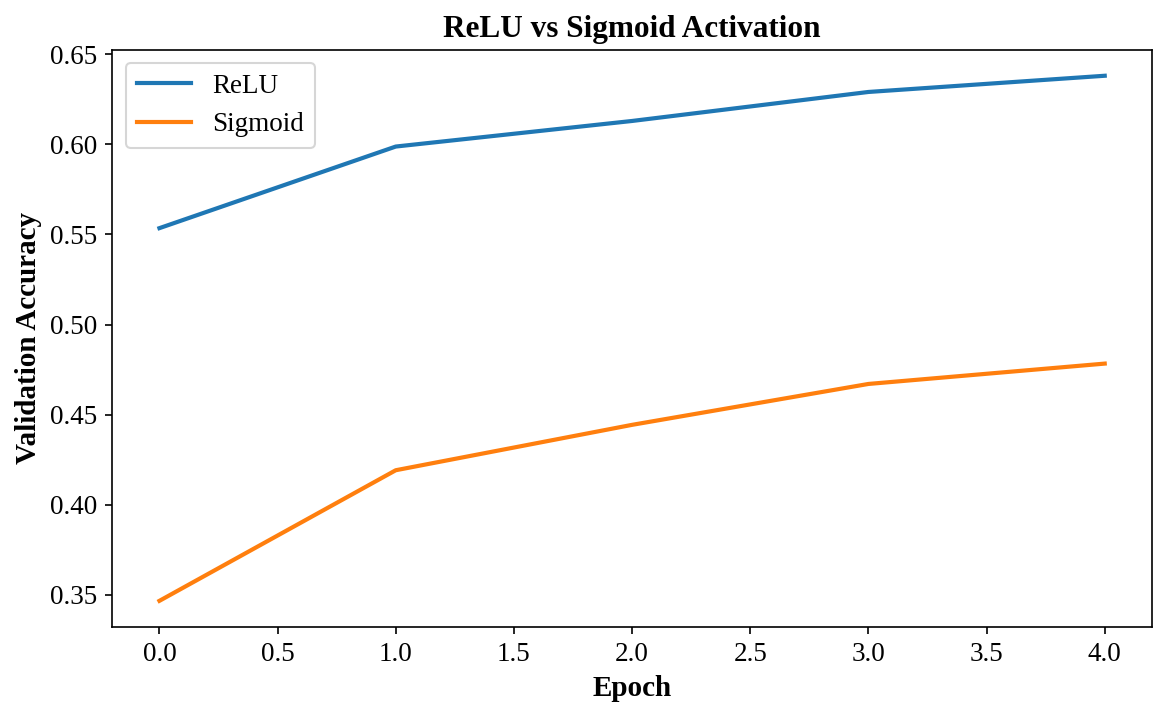

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_relu.history['val_accuracy'], label='ReLU', linewidth=2)
ax.plot(hist_sigmoid.history['val_accuracy'], label='Sigmoid', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy')
ax.set_title('ReLU vs Sigmoid Activation')
ax.legend()
plt.tight_layout()
save_fig(fig, '10_relu_vs_sigmoid.png')
plt.show()


### Exercise 4 — Max Pooling vs Average Pooling
Already addressed in Task 5 above (see `09_pooling_comparison.png` and the printed
val_accuracy / timing comparison).

### Exercise 5 — Filters: 16 vs 64, effect on accuracy and computation time
**Time warning:** two models, 5 epochs each on GPU ≈ under a minute each; the 64-filter
model will take noticeably longer per epoch than the 16-filter one — that's the point
being measured.

In [22]:
def build_filter_model(f1, f2):
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(f1, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Conv2D(f2, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])
    return model

FILTER_EPOCHS = 5

model_f16 = build_filter_model(16, 32)
model_f16.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
hist_f16 = model_f16.fit(x_train_n, y_train_oh, validation_data=(x_test_n, y_test_oh),
                          epochs=FILTER_EPOCHS, batch_size=32, verbose=1)
time_f16 = time.time() - t0

model_f64 = build_filter_model(64, 128)
model_f64.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
hist_f64 = model_f64.fit(x_train_n, y_train_oh, validation_data=(x_test_n, y_test_oh),
                          epochs=FILTER_EPOCHS, batch_size=32, verbose=1)
time_f64 = time.time() - t0

print(f"16 filters -> val_accuracy: {hist_f16.history['val_accuracy'][-1]:.4f}, time: {time_f16:.1f}s")
print(f"64 filters -> val_accuracy: {hist_f64.history['val_accuracy'][-1]:.4f}, time: {time_f64:.1f}s")


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4560 - loss: 1.5136 - val_accuracy: 0.5235 - val_loss: 1.3275
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5879 - loss: 1.1709 - val_accuracy: 0.5904 - val_loss: 1.1567
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6417 - loss: 1.0278 - val_accuracy: 0.6097 - val_loss: 1.1357
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6738 - loss: 0.9391 - val_accuracy: 0.6298 - val_loss: 1.0836
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6951 - loss: 0.8794 - val_accuracy: 0.6459 - val_loss: 1.0438
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4657 - loss: 1.4766 - val_accuracy: 0.5583 - val_loss: 1.2115
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6205 - loss: 1.0757 - val_accuracy: 0.6497 - val_loss: 0.9917
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6742 - loss: 0.9277 - val_a

## Results Summary

In [23]:
print("=== Results Summary ===")
print(f"Training Accuracy (final epoch) : {history.history['accuracy'][-1]:.4f}")
print(f"Testing Accuracy                : {acc:.4f}")
print(f"Precision (macro)               : {prec:.4f}")
print(f"Recall (macro)                   : {rec:.4f}")
print(f"F1-score (macro)                 : {f1:.4f}")
print(f"Total trainable parameters       : {main_model.count_params():,}")


=== Results Summary ===
Training Accuracy (final epoch) : 0.7769
Testing Accuracy                : 0.6745
Precision (macro)               : 0.6823
Recall (macro)                   : 0.6745
F1-score (macro)                 : 0.6740
Total trainable parameters       : 25,578


## Save all plots as a downloadable ZIP
Run this last so you don't lose the plots if the Colab runtime disconnects.

In [24]:
zip_path = '/content/experiment3_plots.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in sorted(os.listdir(PLOTS_DIR)):
        zf.write(os.path.join(PLOTS_DIR, fname), arcname=fname)

print("Zip created:", zip_path)
print("Contents:", os.listdir(PLOTS_DIR))

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not running in Colab — file saved locally at:", zip_path)


Zip created: /content/experiment3_plots.zip
Contents: ['08_confusion_matrix.png', '04_validation_accuracy.png', '10_relu_vs_sigmoid.png', '06_validation_loss.png', '01_sample_images.png', '03_training_accuracy.png', '05_training_loss.png', '07a_feature_maps_untrained.png', '02_class_distribution.png', '09_pooling_comparison.png', '07b_feature_maps_trained.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>